# Statistical Validation of Synthetic Grids


In [ ]:
SYNTHETIC_FILE = "synthetic_grid_metrics.csv"
REAL_FILE      = "real_grid_metrics.csv"
PLZ            =  91301

SCENARIOS = {
    "Baseline": "synthetic_grid_metrics.csv",
    "VariantA": "synthetic_grid_metrics_variant_c.csv",
    "VariantB": "synthetic_grid_metrics_variant_d.csv",
}


In [54]:
import importlib
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = (project_root / ".." / "..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

cn = importlib.import_module("validations.grid_comparison.comparison_notebook")
cn = importlib.reload(cn)

load_and_render_overview        = cn.load_and_render_overview
plot_boxplot_overview           = cn.plot_boxplot_overview
show_distribution_selector      = cn.show_distribution_selector
plot_metric_kde_diagonal        = cn.plot_metric_kde_diagonal
show_wasserstein_summary        = cn.show_wasserstein_summary
plot_correlation_matrix_comparison = cn.plot_correlation_matrix_comparison
load_scenario_metrics             = cn.load_scenario_metrics
compare_scenarios_to_real         = cn.compare_scenarios_to_real
build_scenario_wasserstein_bar_figure = cn.build_scenario_wasserstein_bar_figure
plot_scenario_kde_diagonal        = cn.plot_scenario_kde_diagonal
show_cable_type_comparison        = cn.show_cable_type_comparison

METRICS_DIR    = project_root / "validations" / "metrics"

METRICS = list(cn.DEFAULT_METRICS)
LABELS  = dict(cn.DEFAULT_LABELS)
PALETTE = {"Synthetic": "steelblue", "Real": "crimson"}
REAL_GRID_DIR     = None   # None = GRID_DATA_PATH aus config_loader
MIN_CABLE_SEGMENTS = 100

In [55]:
notebook_data = load_and_render_overview(
    metrics_dir=METRICS_DIR,
    metrics=METRICS,
    labels=LABELS,
    synthetic_metrics_filename=SYNTHETIC_FILE,
    real_metrics_filename=REAL_FILE,
)

### Data Inputs

,source,path,rows
0,Synthetic,/Users/simonnehr/infdb/infdb-demo/pylovo/valid...,98
1,Real,/Users/simonnehr/infdb/infdb-demo/pylovo/valid...,100


### Status-Stratified Diagnostics

,power_flow_status,count
0,converged,45
1,voltage_violation,53


,power_flow_status,synthetic_n,real_n,mean_normalized_wasserstein,median_normalized_wasserstein,worst_metric,worst_normalized_wasserstein
0,converged,45,100,0.3279,0.3059,graph_resistance,0.4078
1,voltage_violation,53,100,0.5461,0.5902,feeder_lines,0.6950


### Primary Wasserstein Score

,metric,synthetic_n,real_n,wasserstein_distance,normalized_wasserstein,quality
0,transformer_mva,98,100,0.0135,0.0587,excellent
1,avg_trafo_distance,98,100,0.0838,0.3177,poor
2,max_trafo_distance,98,100,0.1484,0.3381,acceptable
3,graph_resistance,98,100,0.1141,0.3571,good
4,graph_length,98,100,0.5633,0.3785,poor
5,feeder_lines,98,100,2.5269,0.4212,poor


## Boxplot overview


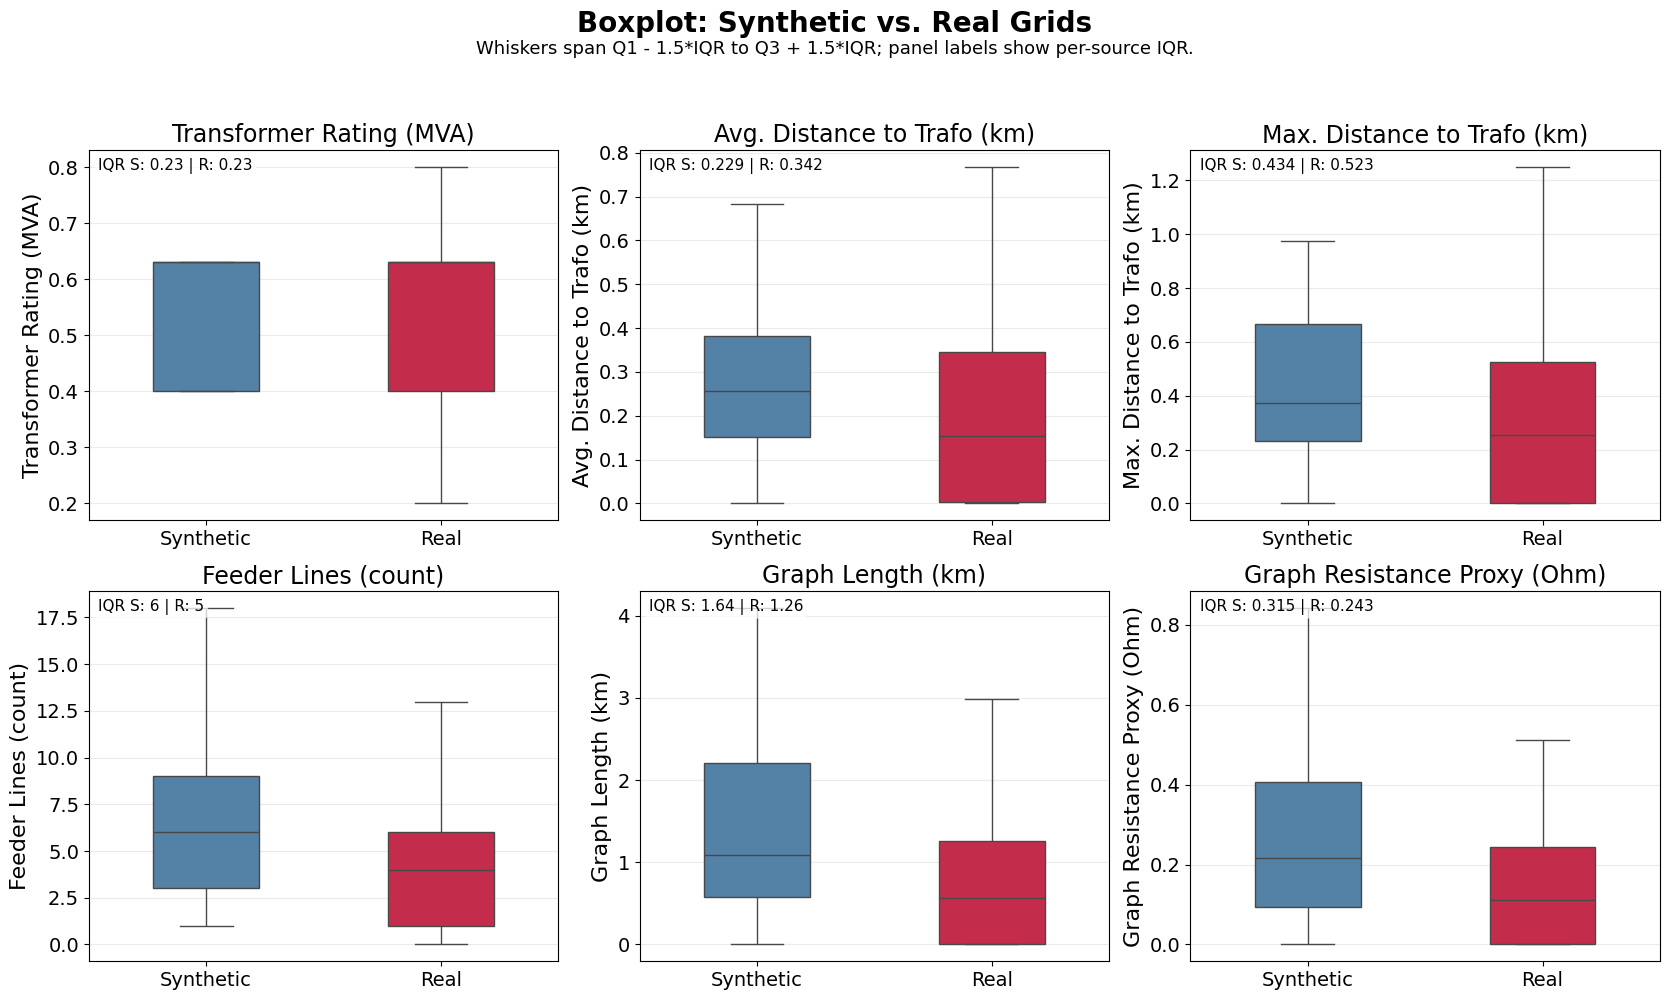

In [56]:
_ = plot_boxplot_overview(
    notebook_data.df_all,
    notebook_data.metrics,
    labels=notebook_data.labels,
    palette=PALETTE,
    title="Boxplot: Synthetic vs. Real Grids",
)

## Kernel Density Estimation (KDE)

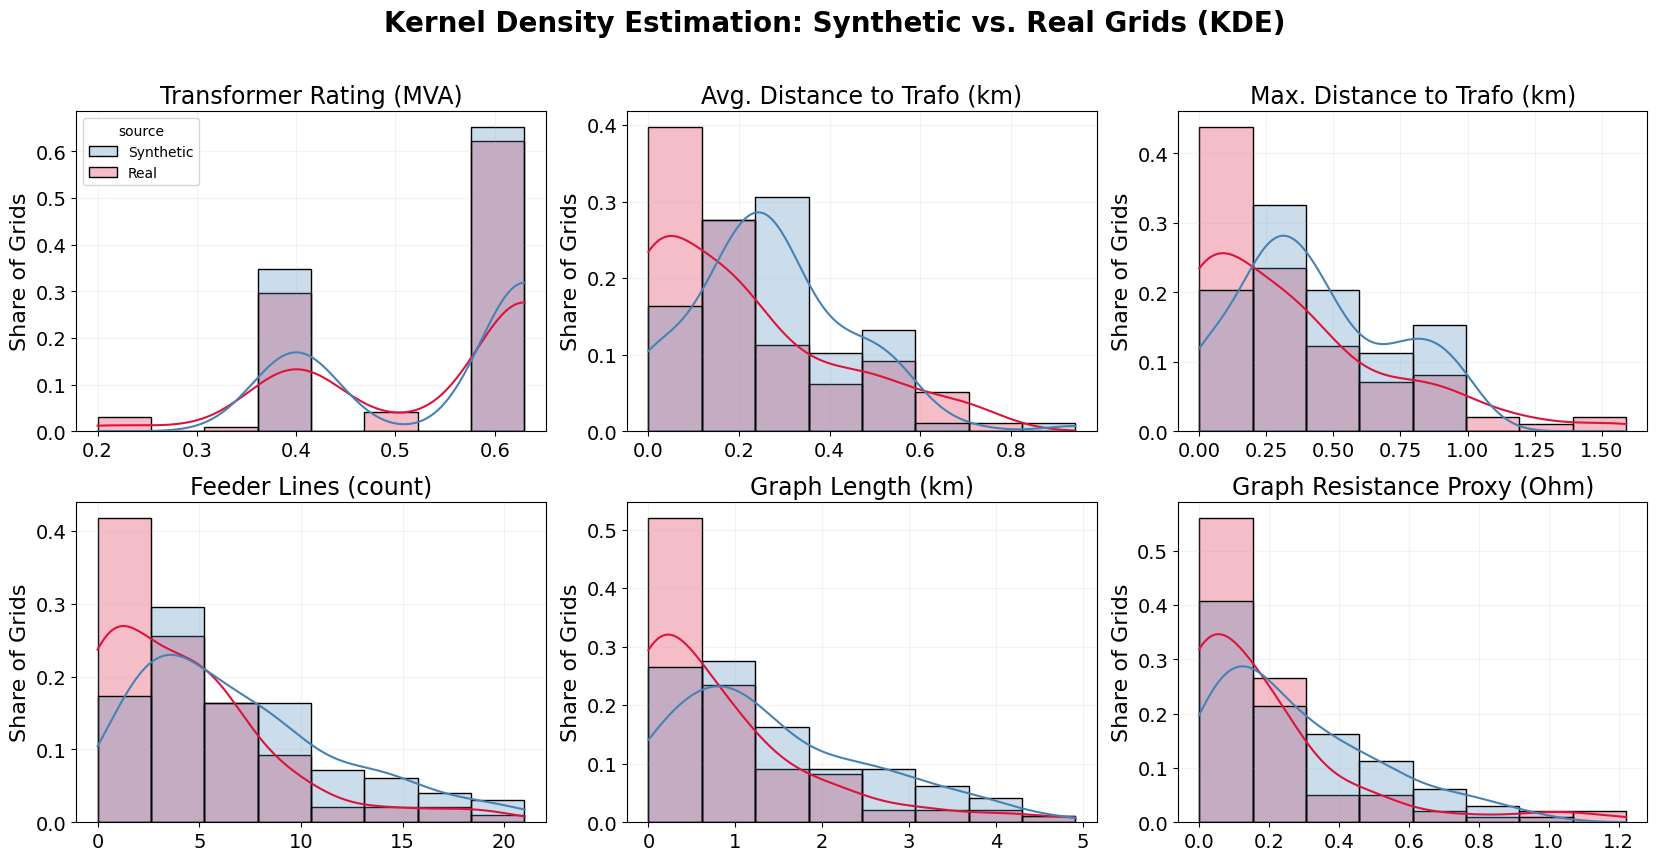

In [57]:
_ = plot_metric_kde_diagonal(
    notebook_data.df_all,
    notebook_data.metrics,
    labels=notebook_data.labels,
    palette=PALETTE,
    show_hist_bars=True,
    bins=8,
    n_cols=3,
    title="Kernel Density Estimation: Synthetic vs. Real Grids (KDE)",
    upper_percentile=0.99,
    clip_nonnegative=True,
)

## Wasserstein Distance

In [58]:
_ = show_wasserstein_summary(notebook_data)

,metric,synthetic_n,real_n,wasserstein_distance,normalized_wasserstein,quality
0,transformer_mva,98,100,0.0135,0.0587,excellent
1,avg_trafo_distance,98,100,0.0838,0.3177,poor
2,max_trafo_distance,98,100,0.1484,0.3381,acceptable
3,graph_resistance,98,100,0.1141,0.3571,good
4,graph_length,98,100,0.5633,0.3785,poor
5,feeder_lines,98,100,2.5269,0.4212,poor


## Cable type analysis


In [59]:
_ = show_cable_type_comparison(
    PLZ,
    real_grid_dir=REAL_GRID_DIR,
    min_segment_count=MIN_CABLE_SEGMENTS,
)

Showing cable types with more than 100 weighted line segments across real and synthetic grids. 

**Total length of the displayed cable types** (Basis for the percentage values in the histogram below):

- **Synthetic:** 494.26 km
- **Real:** 291.62 km

,Cable Type,source,segment_count,total_length_km,impedance_ohm_per_km
0,NS-Leitungstyp_fiktiv,Real,141.0,1.4090,0.0000
1,NAYY_4_300,Synthetic,691.0,16.5275,0.1281
2,NYY-J 3x150SM 0.6/1kV,Real,1533.0,40.4470,0.1453
3,NAYY_4_240,Synthetic,1251.0,24.7256,0.1501
4,NYY-J 4x120,Real,609.0,18.3400,0.1735
5,NAYY_4_185,Synthetic,1295.0,28.8998,0.1825
6,NAYY 4x185SE 0.6/1kV,Real,918.0,30.5090,0.1836
7,NYY-J 3x95SM 0.6/1kV,Real,744.0,18.8790,0.2080
8,NAYBY 4x150sm 0.6/1kV,Real,120.0,2.7580,0.2197
9,NAYY 4x150SE 0.6/1kV,Real,457.0,11.6900,0.2218




- **Synthetic:** 13.12% of material length (64.871 km)
- **Real:** 0.00% of material length (0.008 km)

,source,Cable Type,parallel (count),Occurrences,Material Length (km)
0,Synthetic,NAYY_4_150,2,268,5.1236
1,Synthetic,NAYY_4_120,2,260,9.3148
2,Synthetic,NAYY_4_185,2,188,10.0584
3,Synthetic,NAYY_4_240,2,154,6.8551
4,Synthetic,NYY_4_70,2,143,13.2828
5,Synthetic,NAYY_4_240,3,83,6.9010
6,Synthetic,NAYY_4_300,2,65,3.2275
7,Synthetic,NAYY_4_185,3,39,4.0508
8,Synthetic,NYY_4_70,3,13,2.1916
9,Synthetic,NYY_4_35,2,10,0.6815


## Korrelationsstruktur-Vergleich


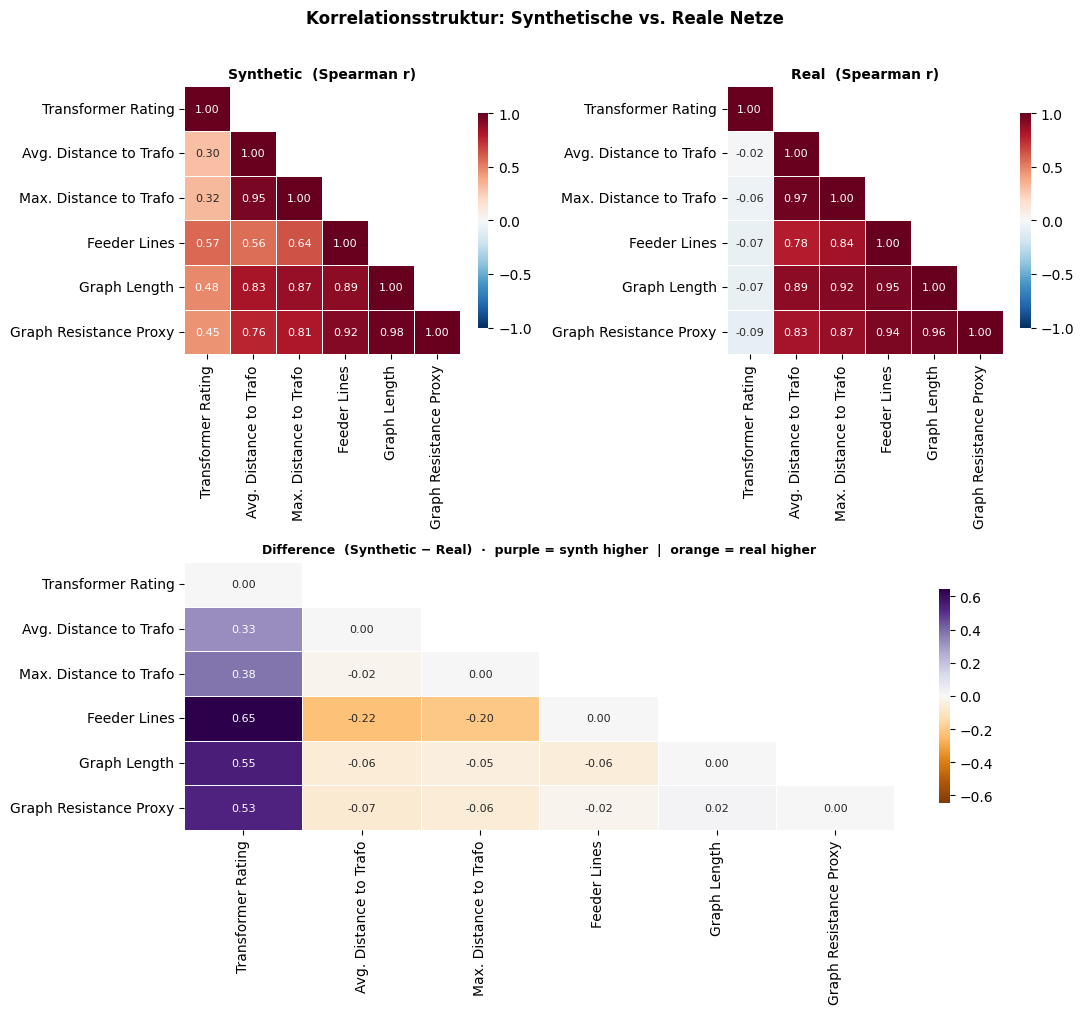

In [60]:
_ = plot_correlation_matrix_comparison(
    notebook_data.df_all,
    notebook_data.metrics,
    labels=notebook_data.labels,
    method="spearman",
    title="Korrelationsstruktur: Synthetische vs. Reale Netze",
)

## More Scenario Comparison (Sensitivitätsanalyse)


In [61]:
SCENARIO_PALETTE = {
    "Baseline": "#4C78A8",
    "VariantA": "#F58518",
    "VariantB": "#54A24B",
    "Real": "crimson",
}

scenario_data = load_scenario_metrics(
    SCENARIOS,
    metrics_dir=METRICS_DIR,
    real_metrics_filename=REAL_FILE,
    dataset_col="dataset",
)
scenario_data["dataset"].value_counts()

dataset
VariantB    129
VariantA    111
Real        100
Baseline     98
Name: count, dtype: int64

### Boxplot overview

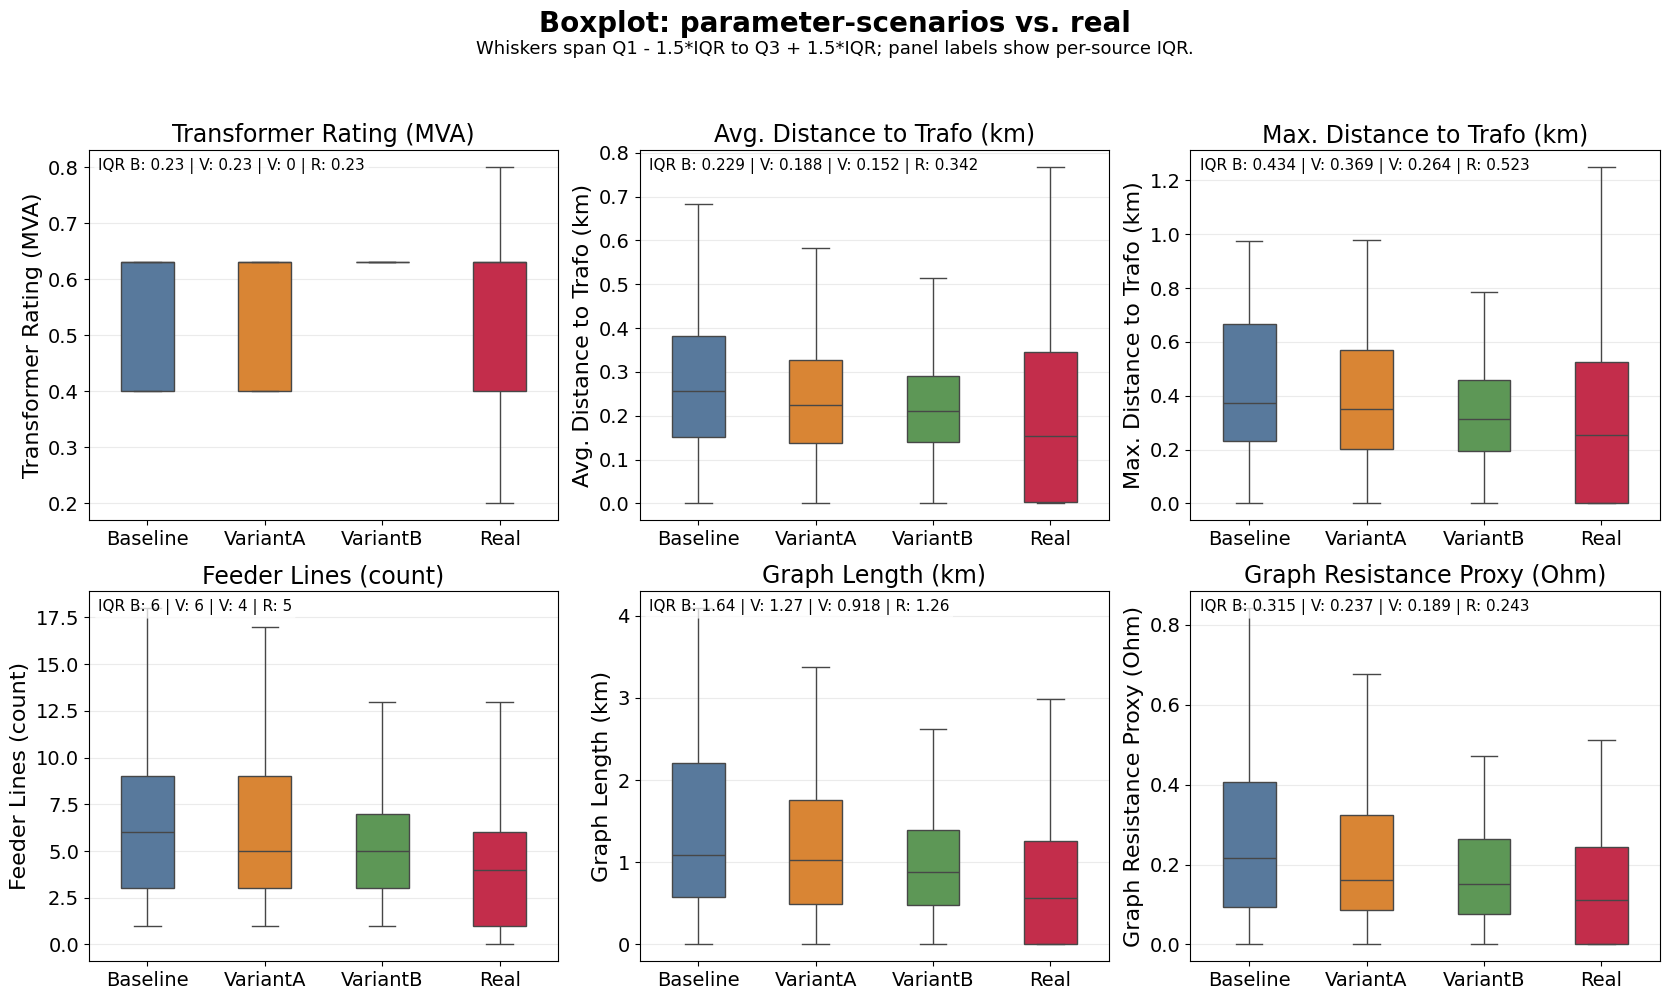

In [62]:
_ = plot_boxplot_overview(
    scenario_data,
    METRICS,
    labels=LABELS,
    source_col="dataset",
    palette=SCENARIO_PALETTE,
    hue_order=list(SCENARIOS.keys()) + ["Real"],
    title="Boxplot: parameter-scenarios vs. real",
)

### Kernel Density Estimation (KDE)

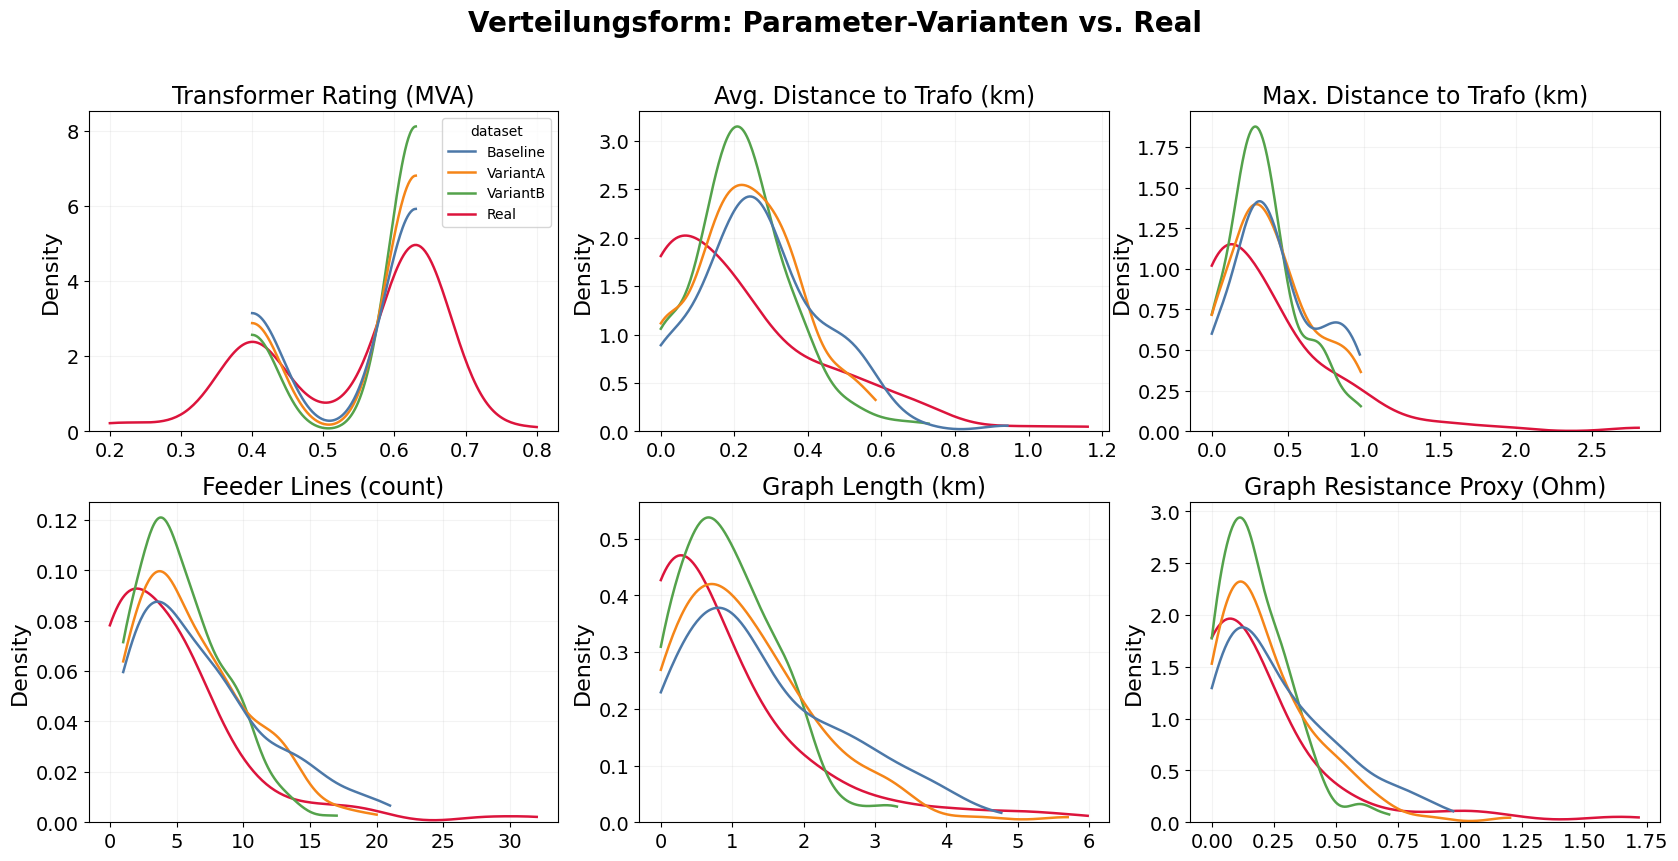

In [63]:
_ = plot_scenario_kde_diagonal(
    SCENARIOS,
    METRICS,
    metrics_dir=METRICS_DIR,
    real_metrics_filename=REAL_FILE,
    labels=LABELS,
    palette=SCENARIO_PALETTE,
    title="Verteilungsform: Parameter-Varianten vs. Real",
)

### Wasserstein Distance


In [64]:
scenario_wasserstein = compare_scenarios_to_real(
    SCENARIOS,
    METRICS,
    metrics_dir=METRICS_DIR,
    real_metrics_filename=REAL_FILE,
)
scenario_wasserstein.round(4)

,dataset,metric,synthetic_n,real_n,wasserstein_distance,pooled_iqr,normalized_wasserstein,quality
0,Baseline,transformer_mva,98,100,0.0135,0.2300,0.0587,excellent
1,Baseline,avg_trafo_distance,98,100,0.0838,0.2639,0.3177,poor
2,Baseline,max_trafo_distance,98,100,0.1484,0.4388,0.3381,acceptable
3,Baseline,graph_resistance,98,100,0.1141,0.3196,0.3571,good
4,Baseline,graph_length,98,100,0.5633,1.4885,0.3785,poor
5,Baseline,feeder_lines,98,100,2.5269,6.0000,0.4212,poor
6,VariantA,transformer_mva,111,100,0.0210,0.2300,0.0914,excellent
7,VariantA,graph_length,111,100,0.3858,1.4129,0.2731,good
8,VariantA,max_trafo_distance,111,100,0.1292,0.4257,0.3035,acceptable
9,VariantA,graph_resistance,111,100,0.0826,0.2560,0.3224,excellent


In [65]:
fig = build_scenario_wasserstein_bar_figure(scenario_wasserstein)
fig.show()